# Physical Experiment Graphs

In [1]:
from pathlib import Path
import io
import re

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper")

# Names used in the plots.
MODEL_NAMES = {
    "opencv_colour": "OpenCV",
    "yolo26n": "YOLO26n",
    "faster_rcnn_mobilenet_v3_320": "Faster R-CNN",
}

MODEL_ORDER = ["OpenCV", "YOLO26n", "Faster R-CNN"]

# Save paper figures here.
FIG_DIR = Path.cwd() / "paper_figures"
FIG_DIR.mkdir(exist_ok=True)

In [2]:
# Find the joined log for each repetition.
def find_log(rep):
    name = f"repetition{rep}_all_logs.txt"

    paths = [
        Path.cwd() / "joined_logs" / name,
        Path.cwd().parent / "joined_logs" / name,
        Path.cwd() / name,
        Path("/mnt/data") / name,
    ]

    for path in paths:
        if path.exists():
            return path

    raise FileNotFoundError(name)


# Split the joined log back into its CSV files.
def read_joined_log(path):
    text = path.read_text(encoding="utf-8")
    parts = re.split(
        r"(?:^|\n)=+\nFILE: (.+?)\n=+\n",
        text,
    )

    files = []

    for i in range(1, len(parts), 2):
        file_name = parts[i].strip()
        csv_text = parts[i + 1].strip()

        if csv_text:
            files.append((file_name, pd.read_csv(io.StringIO(csv_text))))

    return files


attempt_frames = []
summary_frames = []

# Load all three experiment repetitions.
for rep in (1, 2, 3):
    for file_name, frame in read_joined_log(find_log(rep)):
        if file_name.endswith("/attempts.csv"):
            attempt_frames.append(frame)
        elif file_name.endswith("/run_summary.csv"):
            summary_frames.append(frame)

attempts = pd.concat(attempt_frames, ignore_index=True)
summaries = pd.concat(summary_frames, ignore_index=True)

attempts["model"] = attempts["method"].map(MODEL_NAMES)
summaries["model"] = summaries["method"].map(MODEL_NAMES)

# Use attempted pick cycles for the main analysis.
active = attempts[attempts["attempted"] == 1].copy()

print("Pick attempts:", len(active))
print("Runs:", summaries["run_id"].nunique())

Pick attempts: 180
Runs: 81


## Sorting success

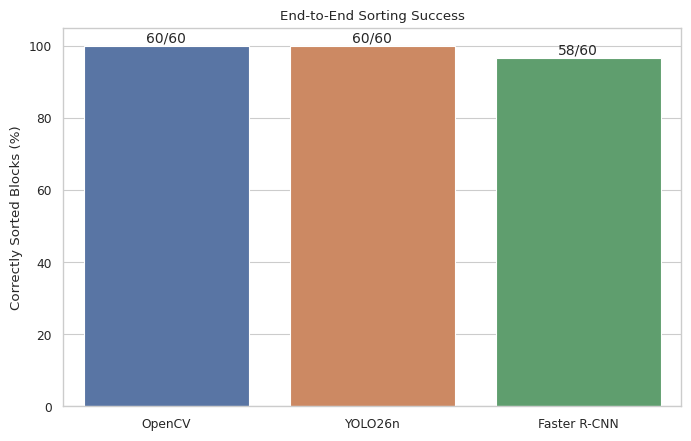

In [3]:
# Count correctly sorted blocks for each detector.
sorting = (
    active.groupby("model")["correct_bin"]
    .sum()
    .reindex(MODEL_ORDER)
)

plot_df = pd.DataFrame({
    "model": MODEL_ORDER,
    "percent": [sorting[m] / 60 * 100 for m in MODEL_ORDER],
    "count": [int(sorting[m]) for m in MODEL_ORDER],
})

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.barplot(
    data=plot_df,
    x="model",
    y="percent",
    hue="model",
    hue_order=MODEL_ORDER,
    legend=False,
    ax=ax,
)

ax.set_title("End-to-End Sorting Success")
ax.set_xlabel("")
ax.set_ylabel("Correctly Sorted Blocks (%)")
ax.set_ylim(0, 105)

for patch, count, percent in zip(ax.patches, plot_df["count"], plot_df["percent"]):
    ax.text(
        patch.get_x() + patch.get_width() / 2,
        percent + 1,
        f"{count}/60",
        ha="center",
        fontsize=10,
    )

fig.tight_layout()
fig.savefig(FIG_DIR / "sorting_success.png", dpi=300, bbox_inches="tight")
fig.savefig(FIG_DIR / "sorting_success.pdf", bbox_inches="tight")
plt.show()

## Scene completion

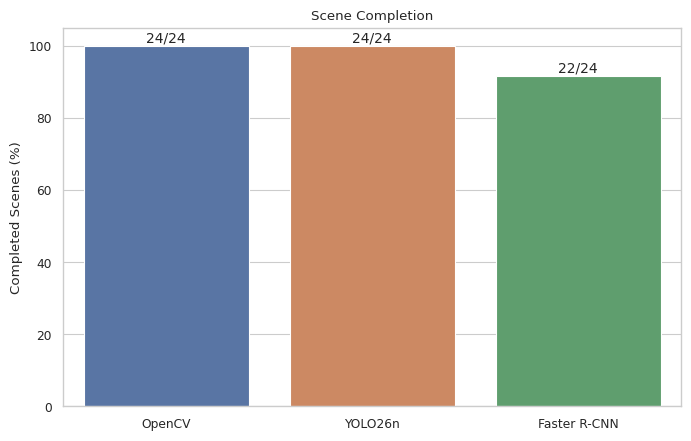

In [4]:
# Exclude the empty scene from scene completion.
scene_data = summaries[summaries["scene_id"] != "s00"]

scene_completion = (
    scene_data.groupby("model")["scene_success"]
    .sum()
    .reindex(MODEL_ORDER)
)

plot_df = pd.DataFrame({
    "model": MODEL_ORDER,
    "percent": [scene_completion[m] / 24 * 100 for m in MODEL_ORDER],
    "count": [int(scene_completion[m]) for m in MODEL_ORDER],
})

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.barplot(
    data=plot_df,
    x="model",
    y="percent",
    hue="model",
    hue_order=MODEL_ORDER,
    legend=False,
    ax=ax,
)

ax.set_title("Scene Completion")
ax.set_xlabel("")
ax.set_ylabel("Completed Scenes (%)")
ax.set_ylim(0, 105)

for patch, count, percent in zip(ax.patches, plot_df["count"], plot_df["percent"]):
    ax.text(
        patch.get_x() + patch.get_width() / 2,
        percent + 1,
        f"{count}/24",
        ha="center",
        fontsize=10,
    )

fig.tight_layout()
fig.savefig(FIG_DIR / "scene_completion.png", dpi=300, bbox_inches="tight")
fig.savefig(FIG_DIR / "scene_completion.pdf", bbox_inches="tight")
plt.show()

## Inference time

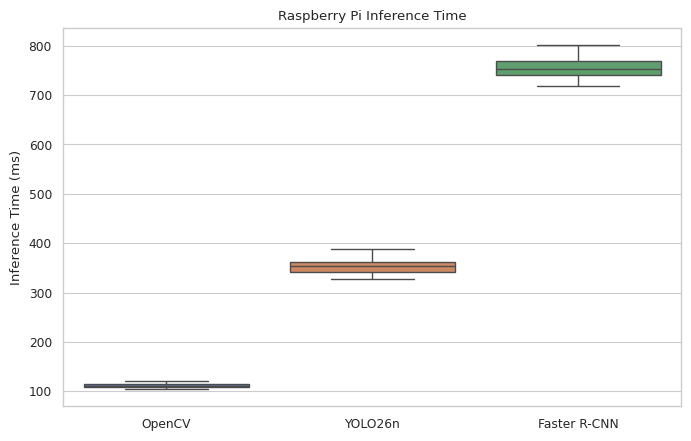

In [5]:
# Compare Raspberry Pi inference times.
fig, ax = plt.subplots(figsize=(7, 4.5))

sns.boxplot(
    data=active,
    x="model",
    y="inference_time_ms",
    order=MODEL_ORDER,
    hue="model",
    hue_order=MODEL_ORDER,
    legend=False,
    showfliers=False,
    ax=ax,
)

ax.set_title("Raspberry Pi Inference Time")
ax.set_xlabel("")
ax.set_ylabel("Inference Time (ms)")
fig.tight_layout()
fig.savefig(FIG_DIR / "inference_time_boxplot.png", dpi=300, bbox_inches="tight")
fig.savefig(FIG_DIR / "inference_time_boxplot.pdf", bbox_inches="tight")
plt.show()

## Inference time by repetition

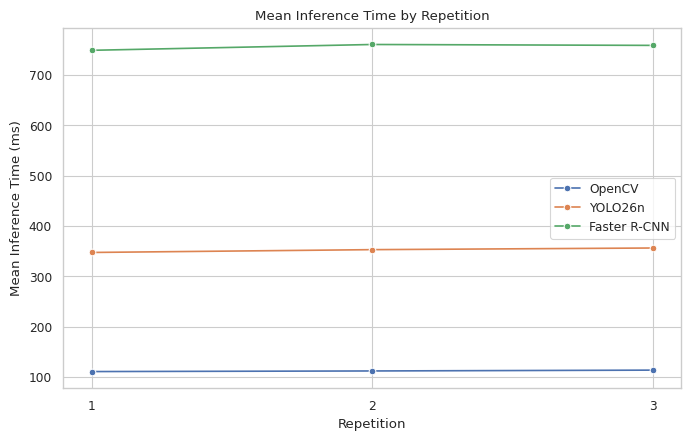

In [6]:
# Check inference time across repetitions.
rep_latency = (
    active.groupby(["repetition", "model"])["inference_time_ms"]
    .mean()
    .reset_index(name="mean_inference_ms")
)

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.lineplot(
    data=rep_latency,
    x="repetition",
    y="mean_inference_ms",
    hue="model",
    hue_order=MODEL_ORDER,
    marker="o",
    dashes=False,
    ax=ax,
)

ax.set_title("Mean Inference Time by Repetition")
ax.set_xlabel("Repetition")
ax.set_ylabel("Mean Inference Time (ms)")
ax.set_xticks([1, 2, 3])
ax.legend(title="")

fig.tight_layout()
fig.savefig(FIG_DIR / "inference_time_by_repetition.png", dpi=300, bbox_inches="tight")
fig.savefig(FIG_DIR / "inference_time_by_repetition.pdf", bbox_inches="tight")
plt.show()

## Pick cycle time

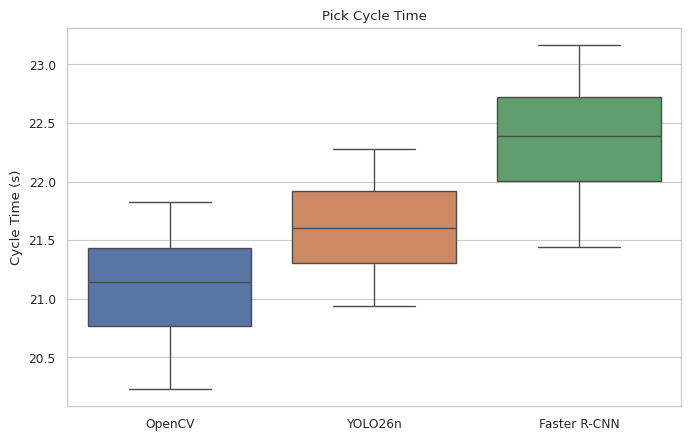

In [7]:
# Convert cycle time to seconds.
cycle_data = active.copy()
cycle_data["cycle_time_s"] = cycle_data["cycle_time_ms"] / 1000

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.boxplot(
    data=cycle_data,
    x="model",
    y="cycle_time_s",
    order=MODEL_ORDER,
    hue="model",
    hue_order=MODEL_ORDER,
    legend=False,
    showfliers=False,
    ax=ax,
)

ax.set_title("Pick Cycle Time")
ax.set_xlabel("")
ax.set_ylabel("Cycle Time (s)")

fig.tight_layout()
fig.savefig(FIG_DIR / "pick_cycle_time_boxplot.png", dpi=300, bbox_inches="tight")
fig.savefig(FIG_DIR / "pick_cycle_time_boxplot.pdf", bbox_inches="tight")
plt.show()

## Wrong bin errors by scene

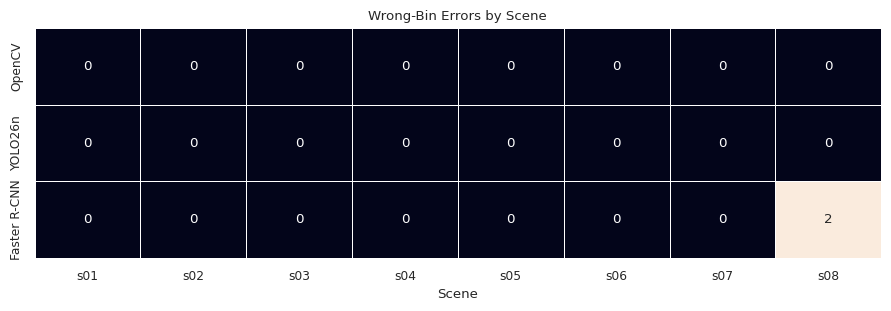

In [8]:
errors = active.copy()
# Count wrong-bin errors by scene.
errors["wrong_bin"] = 1 - errors["correct_bin"]

error_heatmap = (
    errors.groupby(["model", "scene_id"])["wrong_bin"]
    .sum()
    .unstack(fill_value=0)
    .reindex(index=MODEL_ORDER)
    .reindex(columns=[f"s{i:02d}" for i in range(1, 9)], fill_value=0)
)

fig, ax = plt.subplots(figsize=(9, 3.2))

sns.heatmap(
    error_heatmap,
    annot=True,
    fmt=".0f",
    cbar=False,
    linewidths=0.5,
    ax=ax,
)

ax.set_title("Wrong-Bin Errors by Scene")
ax.set_xlabel("Scene")
ax.set_ylabel("")

fig.tight_layout()
fig.savefig(FIG_DIR / "wrong_bin_errors_by_scene.png", dpi=300, bbox_inches="tight")
fig.savefig(FIG_DIR / "wrong_bin_errors_by_scene.pdf", bbox_inches="tight")
plt.show()

## Summary

In [9]:
# Summarise the main physical experiment results.
summary = (
    active.groupby("model")
    .agg(
        picks=("attempted", "sum"),
        successful_picks=("manual_success", "sum"),
        correct_bins=("correct_bin", "sum"),
        mean_inference_ms=("inference_time_ms", "mean"),
        median_inference_ms=("inference_time_ms", "median"),
        mean_cycle_s=("cycle_time_ms", lambda x: x.mean() / 1000),
    )
    .reindex(MODEL_ORDER)
)

summary["completed_scenes"] = scene_completion
summary.round(2)

,picks,successful_picks,correct_bins,mean_inference_ms,median_inference_ms,mean_cycle_s,completed_scenes
model,,,,,,,
OpenCV,60,60.0,60.0,111.99,111.38,21.09,24
YOLO26n,60,60.0,60.0,352.21,353.60,21.56,24
Faster R-CNN,60,60.0,58.0,756.36,752.91,22.37,22
